# 23CSE301 Machine Learning — Capstone Project
## Classification Track — Review 1 (Part A)

**Dataset:** Mental Health & Burnout Prediction Dataset (50,000 records)
**Target variable:** `Mental_Health_Status` (Healthy / Needs Attention / Critical)





In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, classification_report)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.autolayout'] = True

DATA_PATH = 'mental_health_burnout_prediction_dataset.csv'
print('Libraries loaded. Random seed fixed at', RANDOM_STATE)

Libraries loaded. Random seed fixed at 42


## Section A — Dataset & EDA

### A1. Dataset Loading & Audit

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape (rows, columns):', df.shape)
df.head()

Shape (rows, columns): (50000, 40)


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low


In [3]:
print('--- Column dtypes ---')
print(df.dtypes)

--- Column dtypes ---
Person_ID                          int64
Age                              float64
Gender                               str
Country                              str
Occupation                           str
Education_Level                      str
Employment_Status                    str
Monthly_Income_USD               float64
Work_Hours_Per_Week                int64
Remote_Work                          str
Job_Satisfaction                 float64
Work_Life_Balance                float64
Sleep_Hours                      float64
Sleep_Quality                        str
Stress_Level                         str
Anxiety_Score                    float64
Depression_Score                 float64
Mood_Score                       float64
Emotional_Stability                int64
Physical_Activity_Hours          float64
Exercise_Frequency                   str
Meditation_Minutes               float64
Screen_Time_Hours                float64
Social_Media_Hours               fl

In [4]:
print('--- Missing value counts (columns with at least one NaN) ---')
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print()
print('Total missing cells:', df.isna().sum().sum(), 'out of', df.shape[0]*df.shape[1])

--- Missing value counts (columns with at least one NaN) ---


Monthly_Income_USD         1450
Meditation_Minutes         1200
Physical_Activity_Hours    1100
Sleep_Hours                 950
Productivity_Score          950
Mood_Score                  900
Screen_Time_Hours           850
Depression_Score            850
Anxiety_Score               800
Gaming_Hours                750
Life_Satisfaction           700
Work_Life_Balance           650
Social_Media_Hours          600
Job_Satisfaction            500
Therapy_Attendance          400
Age                         250
dtype: int64

Total missing cells: 12900 out of 2000000


In [5]:
print('--- Target class distribution: Mental_Health_Status ---')
print(df['Mental_Health_Status'].value_counts())
print()
print(df['Mental_Health_Status'].value_counts(normalize=True).round(3) * 100, '(%)')

--- Target class distribution: Mental_Health_Status ---
Mental_Health_Status
Healthy            25369
Needs Attention    14096
Critical           10535
Name: count, dtype: int64

Mental_Health_Status
Healthy            50.7
Needs Attention    28.2
Critical           21.1
Name: proportion, dtype: float64 (%)


The dataset has 50,000 rows and 40 columns. Several numeric columns
(`Age`, `Monthly_Income_USD`, `Job_Satisfaction`, `Sleep_Hours`, `Anxiety_Score`, etc.) have
between 400–1,450 missing values each (under 3% of rows), which is manageable with imputation.
The target `Mental_Health_Status` is **imbalanced**: Healthy (~50.7%), Needs Attention (~28.2%),
Critical (~21.1%). This class imbalance means overall accuracy alone can be misleading, so we have
also reported weighted F1-score, per-class precision/recall, and confusion matrices, and we will use
a **stratified** train/test split so class proportions are preserved in both sets.

### A2. Exploratory Data Analysis — Visualisations

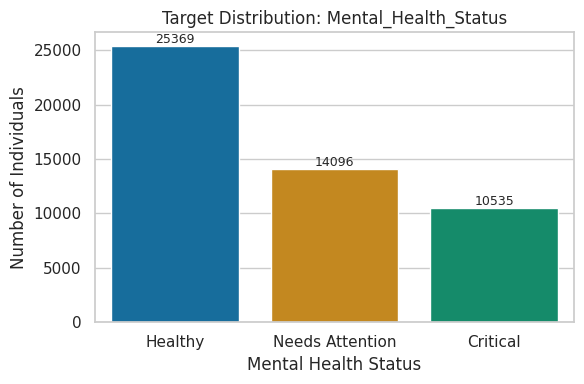

In [6]:
target_order = ['Healthy', 'Needs Attention', 'Critical']
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Mental_Health_Status', order=target_order, palette='colorblind', ax=ax)
ax.set_title('Target Distribution: Mental_Health_Status')
ax.set_xlabel('Mental Health Status')
ax.set_ylabel('Number of Individuals')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Numeric columns: ['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score']


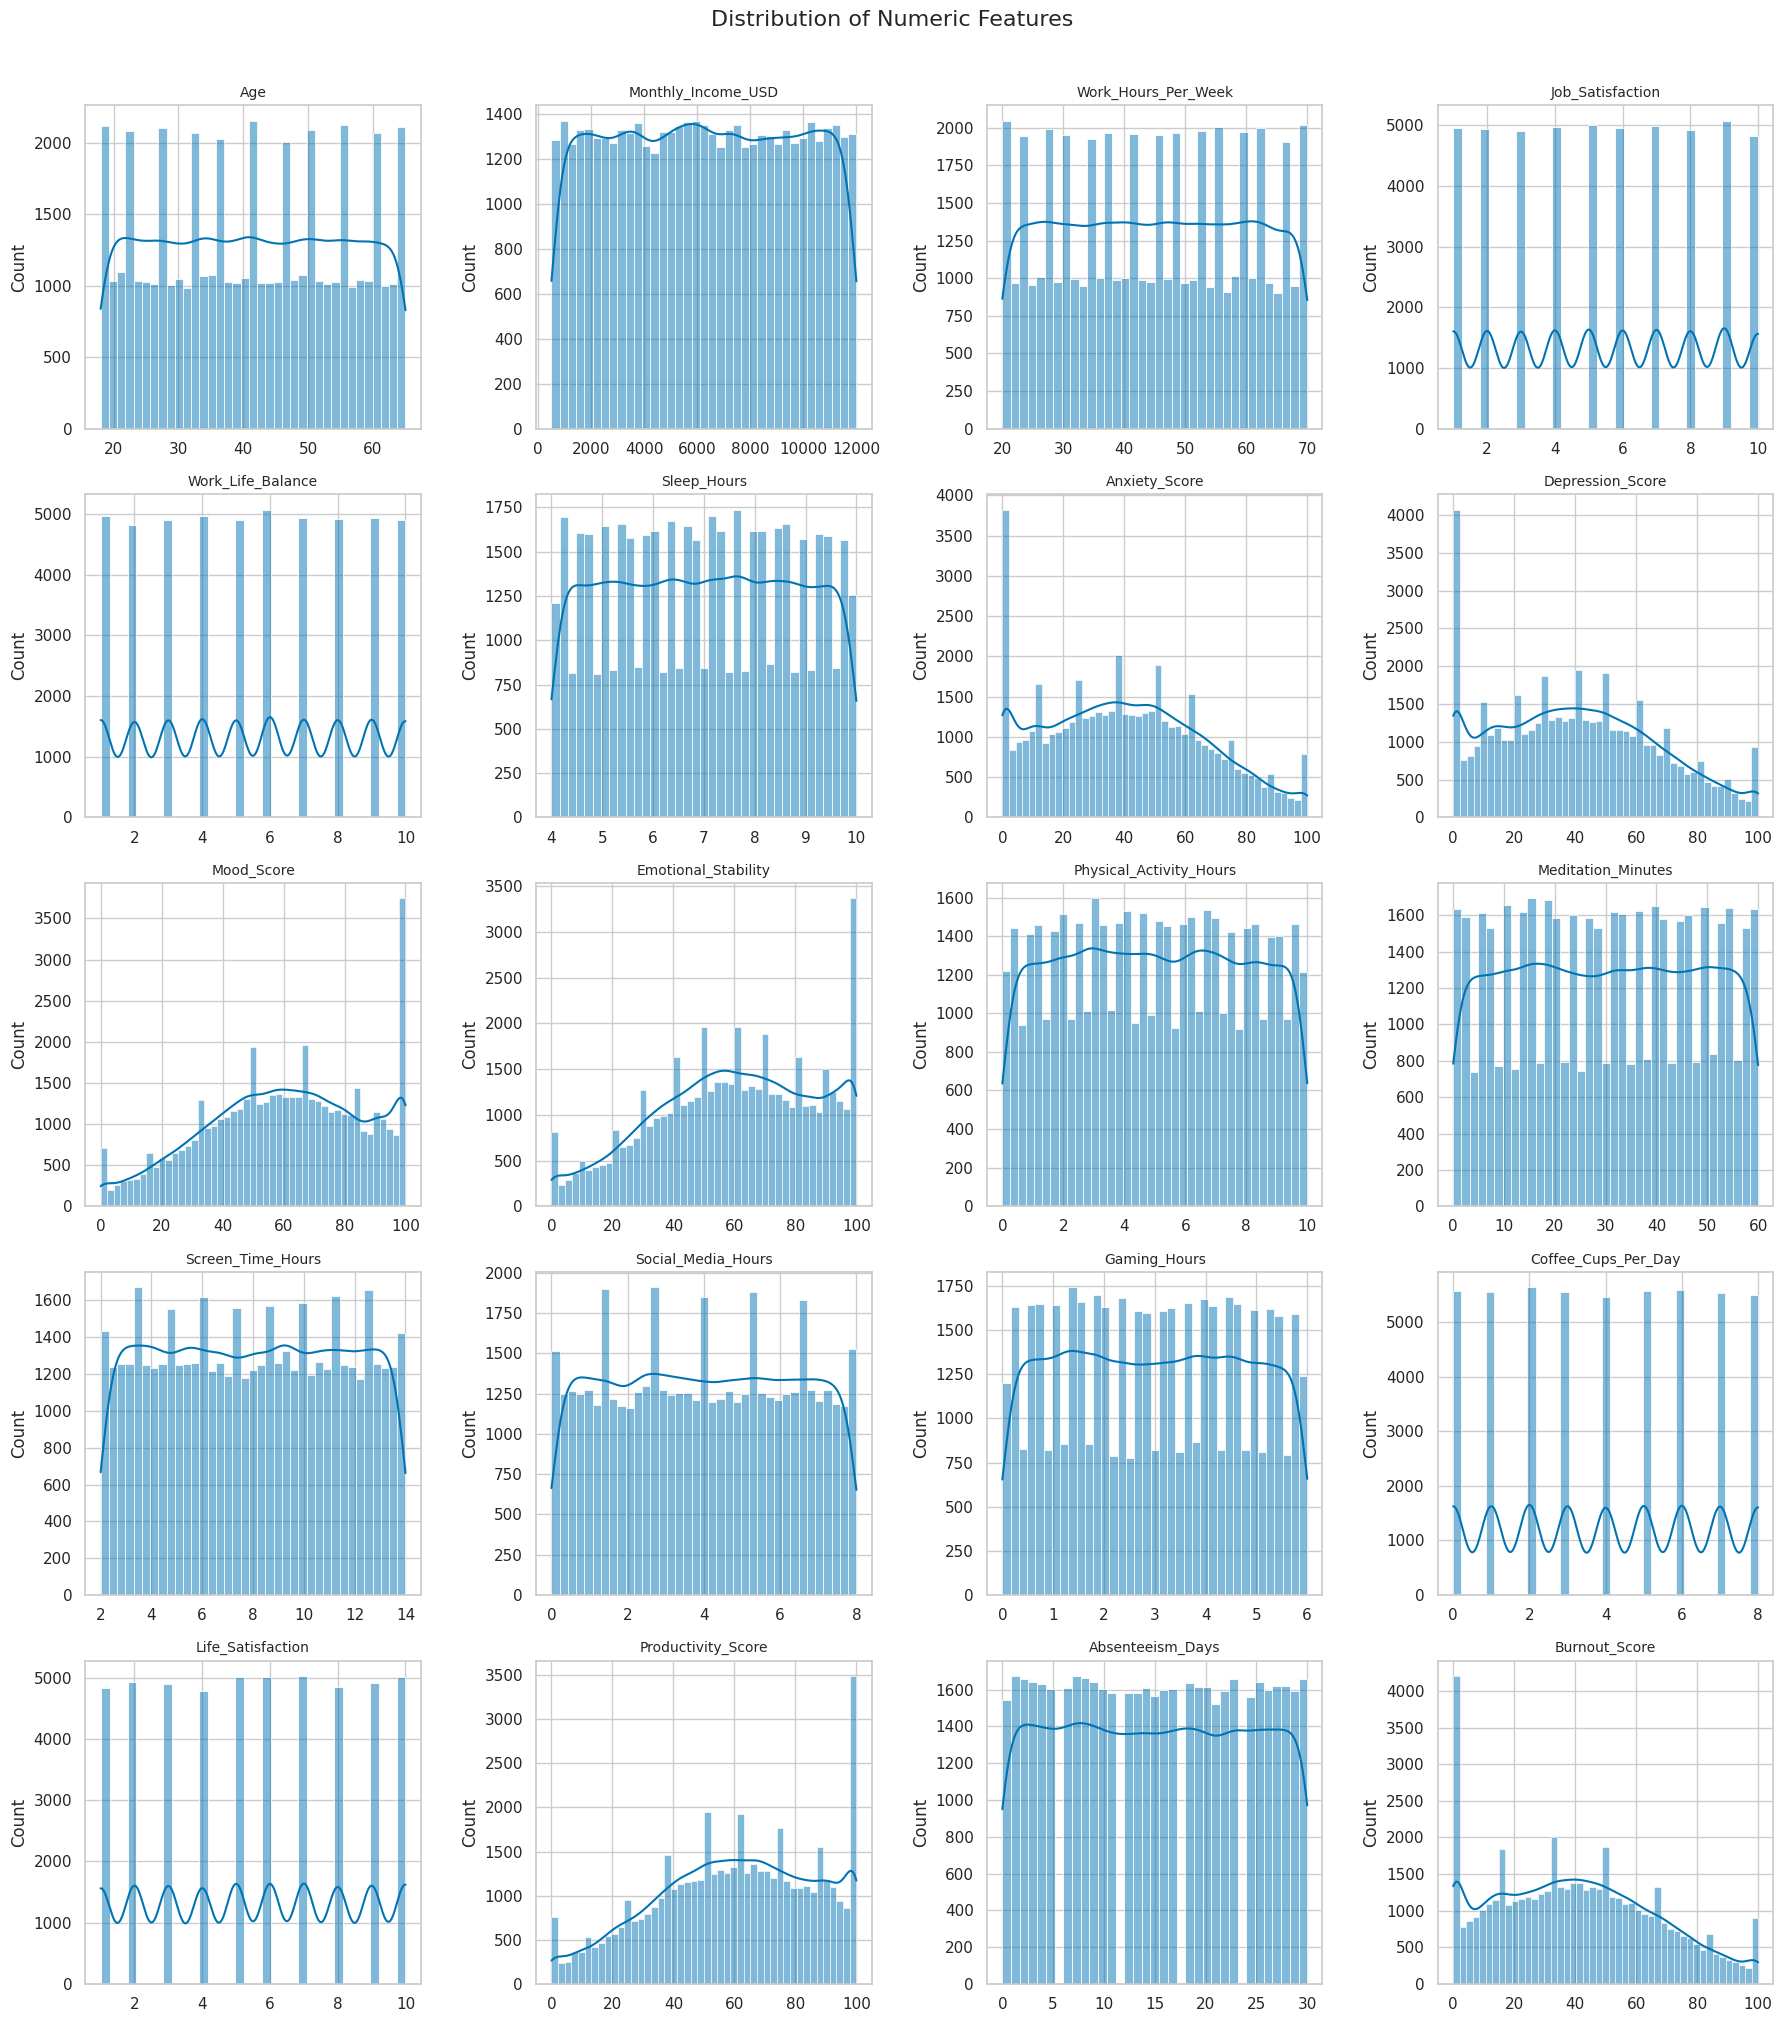

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Person_ID']
print('Numeric columns:', numeric_cols)

n_cols_grid = 4
n_rows_grid = int(np.ceil(len(numeric_cols) / n_cols_grid))
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, 4 * n_rows_grid))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color=sns.color_palette('colorblind')[0])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('Distribution of Numeric Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

 `Age`, `Sleep_Hours`, `Work_Life_Balance`, `Job_Satisfaction`
and `Life_Satisfaction` look roughly uniform/normal with no extreme skew.

`Screen_Time_Hours`,
`Social_Media_Hours`, `Gaming_Hours`, `Meditation_Minutes` and `Absenteeism_Days` are right-skewed
with long tails, which is expected — most people report low-to-moderate usage/absence, with a
smaller group reporting much higher values.

`Anxiety_Score`, `Depression_Score`, `Mood_Score` and
`Emotional_Stability` show wider spreads, consistent with these being the core psychological
indicators that drive the target label.

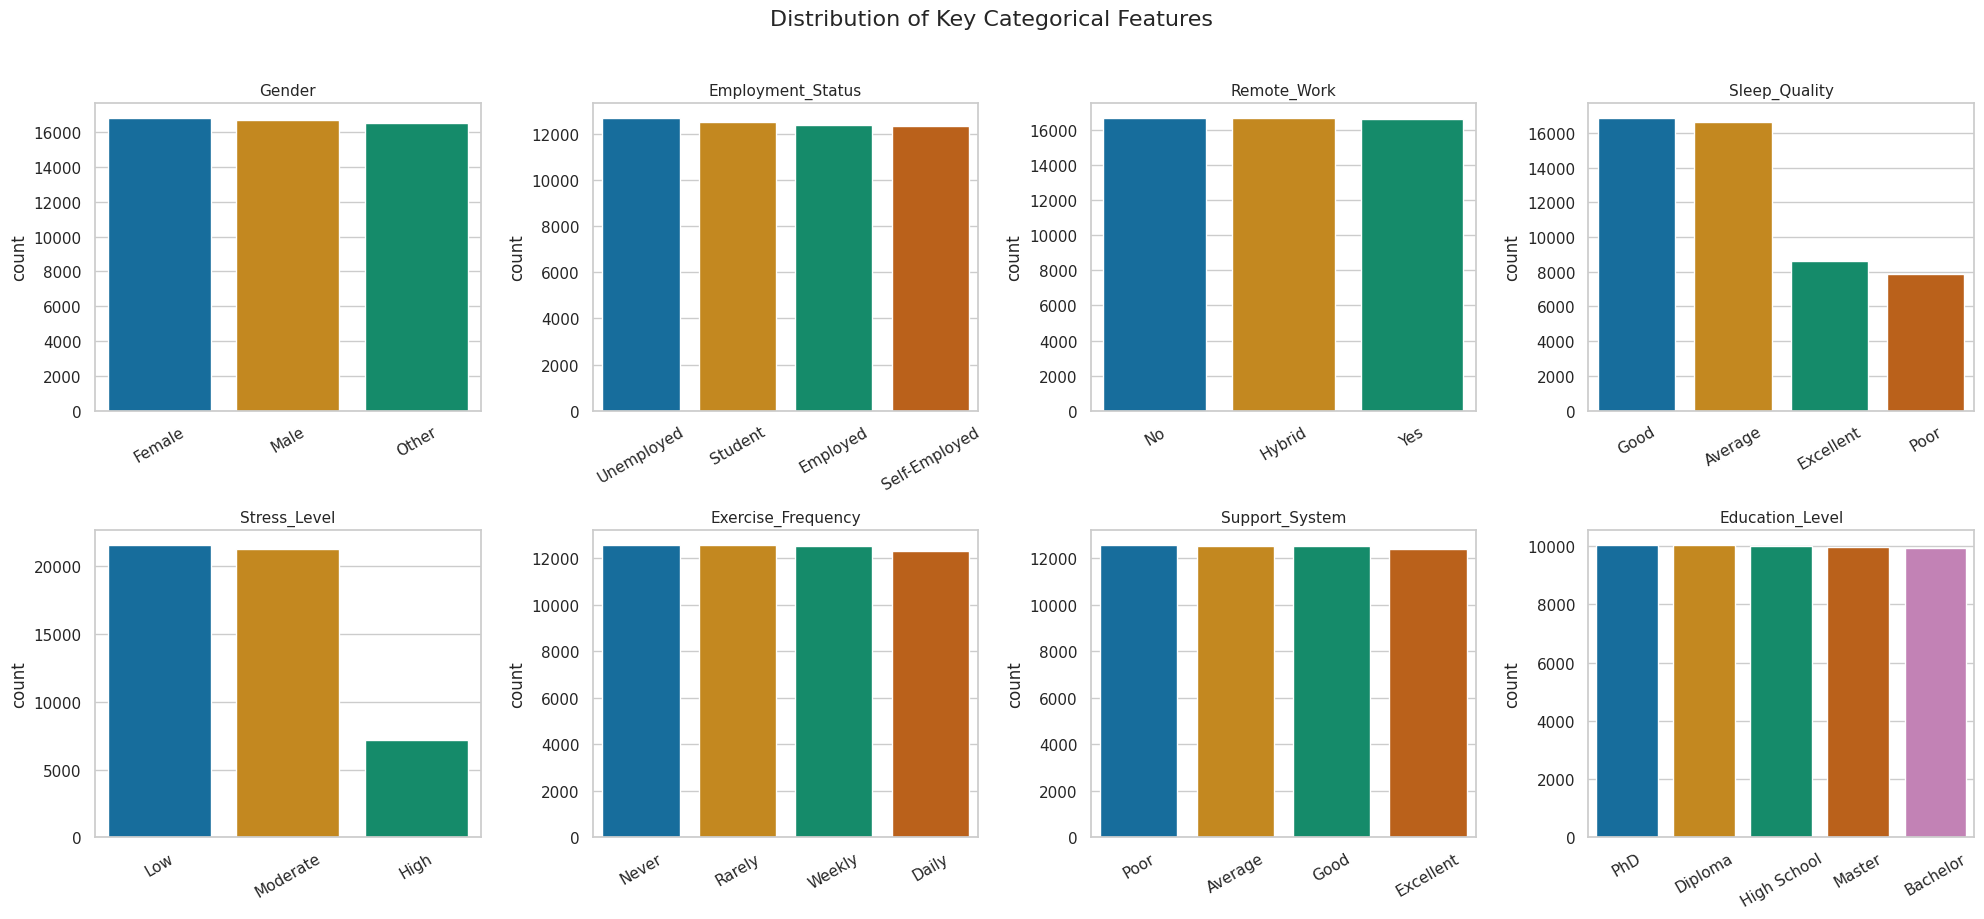

In [8]:
categorical_cols_plot = ['Gender', 'Employment_Status', 'Remote_Work', 'Sleep_Quality',
                          'Stress_Level', 'Exercise_Frequency', 'Support_System', 'Education_Level']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(categorical_cols_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='colorblind', ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')
fig.suptitle('Distribution of Key Categorical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

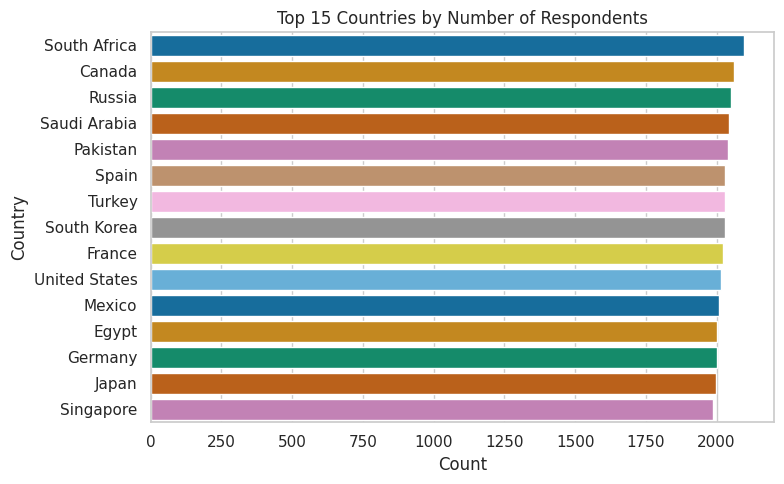

In [9]:
plt.figure(figsize=(8, 5))
top_countries = df['Country'].value_counts().nlargest(15)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='colorblind')
plt.title('Top 15 Countries by Number of Respondents')
plt.xlabel('Count')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

Gender, employment status and remote-work arrangement are
fairly balanced across categories.

`Country` has 25 unique values but respondents are spread
reasonably evenly (no single country dominates),

`Occupation` similarly has 20 fairly balanced
categories — this informs our encoding strategy below (one-hot encoding is feasible without an
explosion of near-empty columns).

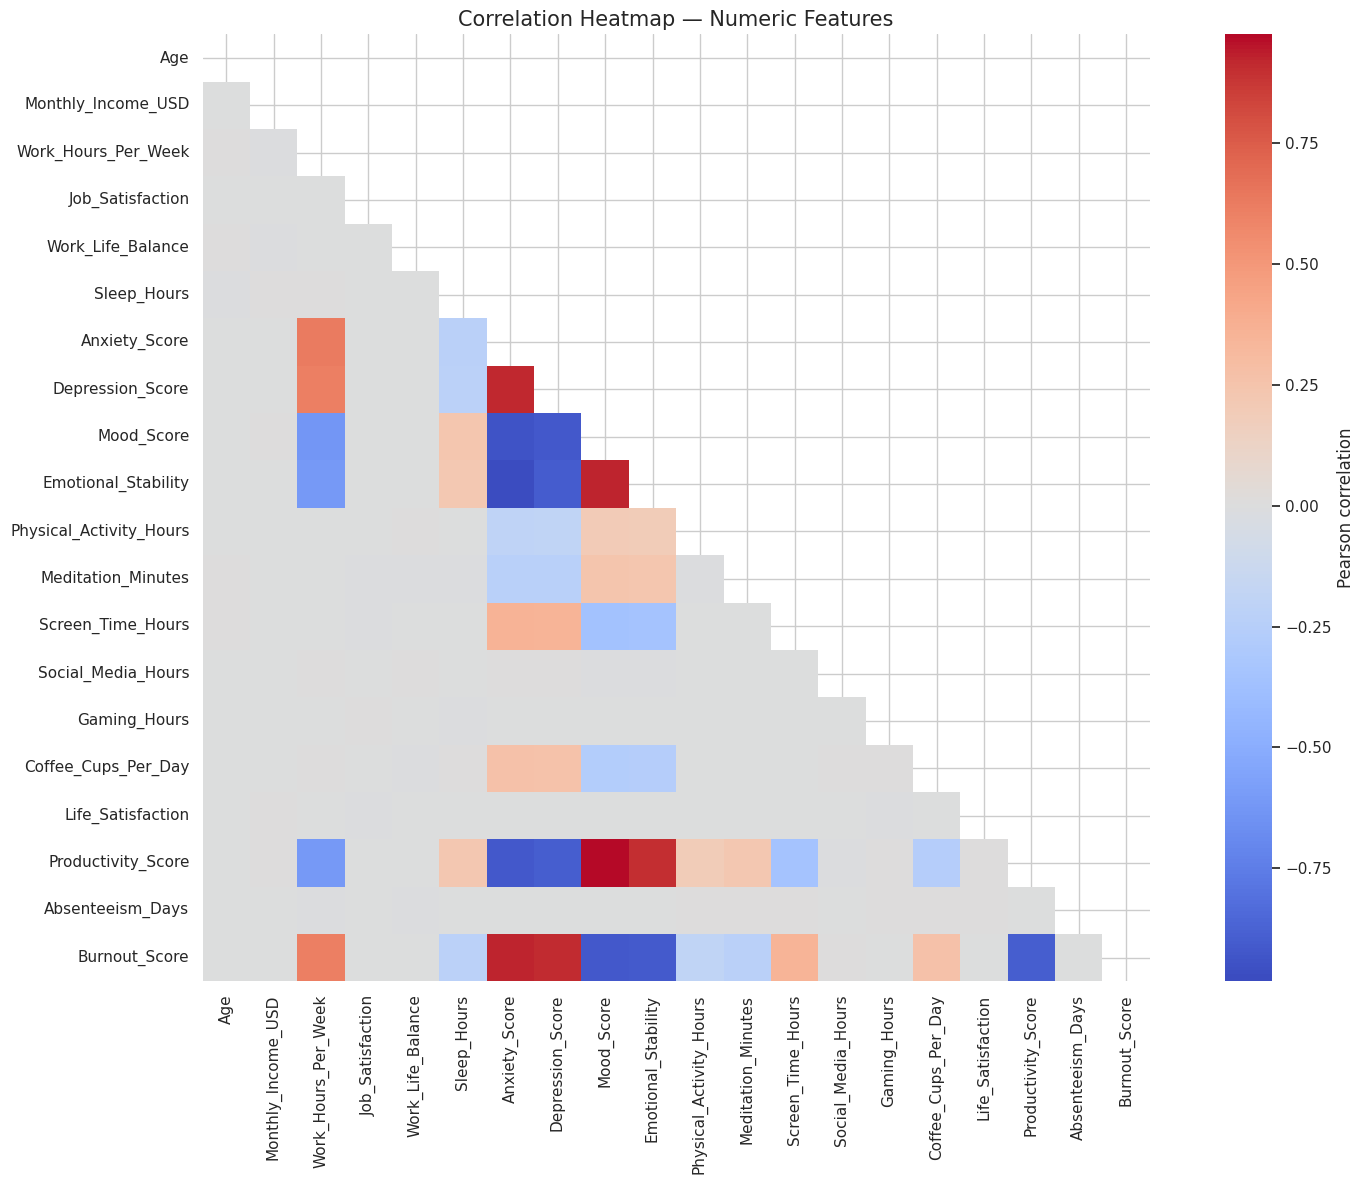

In [10]:
plt.figure(figsize=(16, 12))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=False, square=True,
            cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation Heatmap — Numeric Features', fontsize=15)
plt.tight_layout()
plt.show()

`Burnout_Score` correlates very strongly with
`Anxiety_Score`, `Depression_Score`, `Mood_Score` (negative) and `Emotional_Stability` (negative) —
these are the psychological indicators that were used to construct the synthetic burnout/mental-health
label.

Lifestyle numeric features (`Sleep_Hours`, `Physical_Activity_Hours`, `Screen_Time_Hours`,
`Coffee_Cups_Per_Day`) show weaker but sensible correlations with the psychological scores.

 No
pair of *predictor* features shows extreme multicollinearity (|r| > 0.9), so we do not need to drop
predictors purely for collinearity reasons.

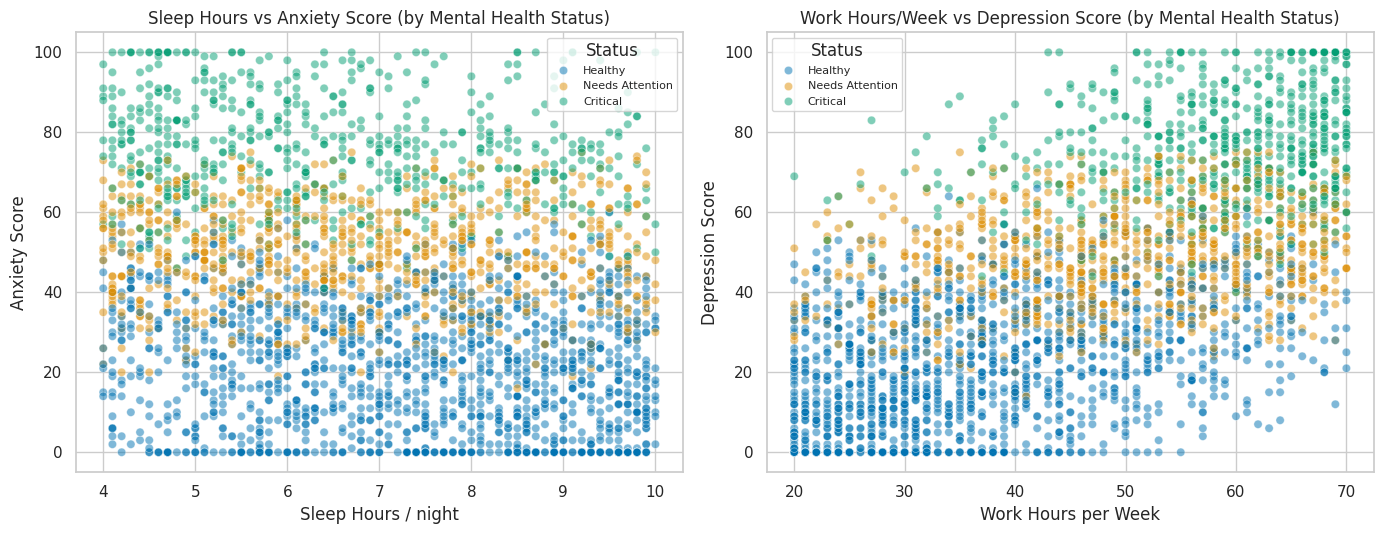

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='Sleep_Hours', y='Anxiety_Score',
                hue='Mental_Health_Status', hue_order=target_order, alpha=0.5, ax=axes[0], palette='colorblind')
axes[0].set_title('Sleep Hours vs Anxiety Score (by Mental Health Status)')
axes[0].set_xlabel('Sleep Hours / night')
axes[0].set_ylabel('Anxiety Score')
axes[0].legend(title='Status', fontsize=8)

sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='Work_Hours_Per_Week', y='Depression_Score',
                hue='Mental_Health_Status', hue_order=target_order, alpha=0.5, ax=axes[1], palette='colorblind')
axes[1].set_title('Work Hours/Week vs Depression Score (by Mental Health Status)')
axes[1].set_xlabel('Work Hours per Week')
axes[1].set_ylabel('Depression Score')
axes[1].legend(title='Status', fontsize=8)

plt.tight_layout()
plt.show()

Individuals in the *Critical* category
cluster at lower sleep hours combined with higher anxiety scores, while *Healthy* individuals
cluster at higher sleep / lower anxiety — consistent with sleep deprivation being a known risk
factor.

Similarly, higher weekly work hours co-occur with higher depression scores, and the
*Critical* group visibly skews toward the high-work-hours / high-depression-score region. These two
relationships motivate the engineered features created in Section B3.

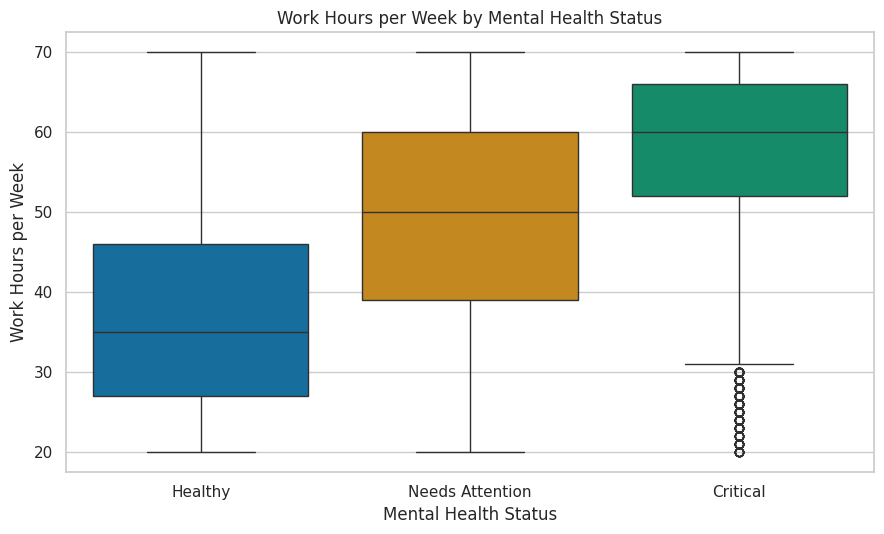

In [12]:
plt.figure(figsize=(9, 5.5))
sns.boxplot(data=df, x='Mental_Health_Status', y='Work_Hours_Per_Week', order=target_order, palette='colorblind')
plt.title('Work Hours per Week by Mental Health Status')
plt.xlabel('Mental Health Status')
plt.ylabel('Work Hours per Week')
plt.tight_layout()
plt.show()

Median weekly work hours rise noticeably from *Healthy* → *Needs Attention* →
*Critical*, reinforcing `Work_Hours_Per_Week` as a useful predictor.

## Section B — Preprocessing & Feature Engineering

### B1. Data Cleaning

We handle three things here: **duplicate rows**, **missing values**, and **outliers**. We also drop
columns that are not legitimate predictors (an identifier, and columns that directly encode the
target under a different name).

In [13]:
# --- Duplicate check ---
n_dupes = df.drop(columns=['Person_ID']).duplicated().sum()
print(f'Duplicate rows (ignoring Person_ID): {n_dupes}')
if n_dupes > 0:
    df = df.drop_duplicates(subset=[c for c in df.columns if c != 'Person_ID']).reset_index(drop=True)
    print('Duplicates removed. New shape:', df.shape)
else:
    print('No duplicate records found — no rows removed.')

Duplicate rows (ignoring Person_ID): 0
No duplicate records found — no rows removed.


**Dropping leakage / non-predictive columns.**

`Person_ID` is a unique identifier with no
predictive value.

`Burnout_Score` and `Burnout_Risk` are near-perfect derivatives of the target
itself (verified below) — `Burnout_Risk` maps almost 1-to-1 onto `Mental_Health_Status`, and
`Burnout_Score` correlates with the target at r ≈ 0.91 because the label was constructed directly
from it.

`AI_Wellness_Recommendation` is a downstream recommendation generated *from* the status,
so it would also leak the answer.

 All four are dropped before modelling to avoid data leakage.

In [14]:
print('Cross-tab confirming Burnout_Risk / Mental_Health_Status leakage:')
pd.crosstab(df['Mental_Health_Status'], df['Burnout_Risk'])

Cross-tab confirming Burnout_Risk / Mental_Health_Status leakage:


Burnout_Risk,High,Low,Moderate
Mental_Health_Status,,,
Critical,9851,0,684
Healthy,0,25369,0
Needs Attention,0,0,14096


In [15]:
LEAKAGE_COLS = ['Person_ID', 'Burnout_Score', 'Burnout_Risk', 'AI_Wellness_Recommendation']
TARGET = 'Mental_Health_Status'

df_model = df.drop(columns=LEAKAGE_COLS).copy()
print('Columns dropped:', LEAKAGE_COLS)
print('Remaining shape for modelling:', df_model.shape)

Columns dropped: ['Person_ID', 'Burnout_Score', 'Burnout_Risk', 'AI_Wellness_Recommendation']
Remaining shape for modelling: (50000, 36)


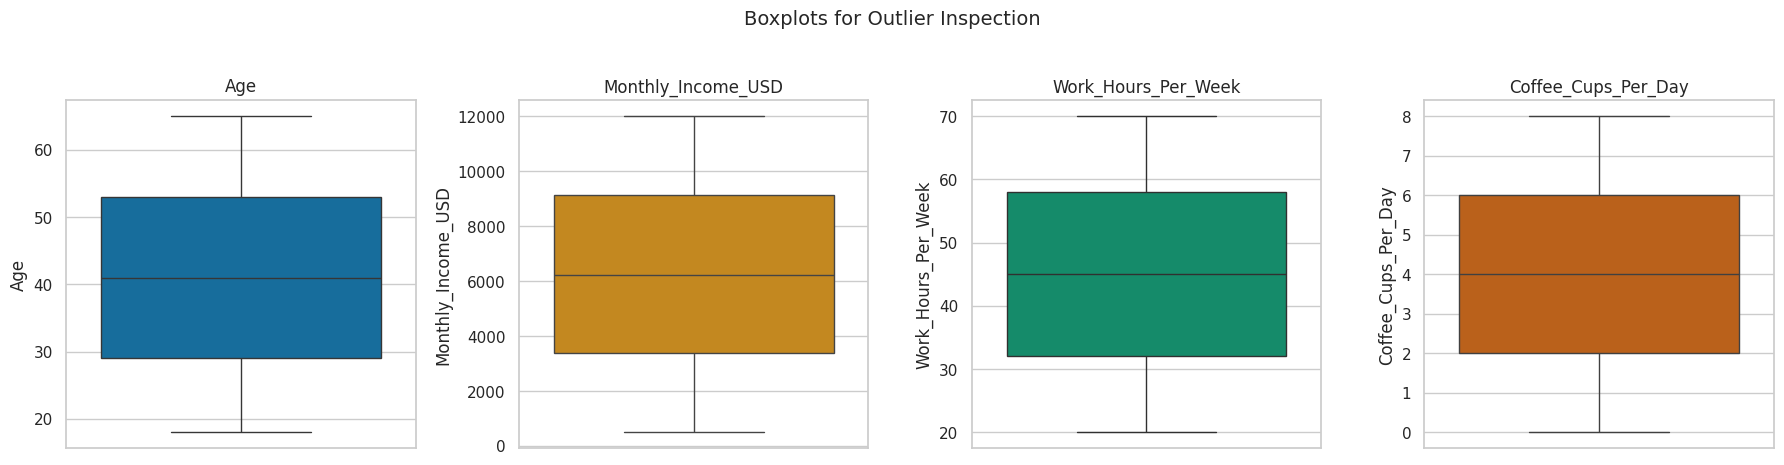

In [16]:
# --- Outlier check (visual) on a few skew-prone numeric columns ---
outlier_check_cols = ['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Coffee_Cups_Per_Day']
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for i, col in enumerate(outlier_check_cols):
    sns.boxplot(y=df_model[col], ax=axes[i], color=sns.color_palette('colorblind')[i])
    axes[i].set_title(col)
plt.suptitle('Boxplots for Outlier Inspection', y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
# --- Outlier count (1.5x IQR rule) - quantifies exactly what the boxplots above show ---
for col in outlier_check_cols:
    q1, q3 = df_model[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_below = (df_model[col] < lower).sum()
    n_above = (df_model[col] > upper).sum()
    print(f'{col:22s}: raw IQR bounds [{lower:9.2f}, {upper:9.2f}]  ->  below: {n_below:4d}  above: {n_above:4d}')

Age                   : raw IQR bounds [    -7.00,     89.00]  ->  below:    0  above:    0
Monthly_Income_USD    : raw IQR bounds [ -5248.50,  17763.50]  ->  below:    0  above:    0
Work_Hours_Per_Week   : raw IQR bounds [    -7.00,     97.00]  ->  below:    0  above:    0
Coffee_Cups_Per_Day   : raw IQR bounds [    -4.00,     12.00]  ->  below:    0  above:    0



The boxplots show **no points beyond the 1.5×IQR whiskers** for any of the four columns — every
value in the dataset already falls inside the fence, confirmed by the exact counts printed above
(0 below, 0 above, in all four columns). So no row in this dataset actually needs to be capped.

We still compute and apply IQR-based capping (fit on the **training set only**, after the split
below) as a safeguard against future or unseen data that could contain genuine extremes — this
keeps the pipeline robust even though it changes nothing here.


for `Age` and `Coffee_Cups_Per_Day`  `Q1 - 1.5×IQR` produces a **negative**
lower bound (e.g. an age of -7, a coffee count of -4). A negative value is not a real outlier
boundary here, it's an artefact of the formula — nobody's age or daily coffee count can be
negative. We therefore **floor the lower bound at 0** for every capped column before clipping,
rather than using the raw (and physically impossible) IQR result.

In [18]:
# --- Missing value strategy note ---
print('Missing values per column (post leakage-column drop):')
print(df_model.isna().sum()[df_model.isna().sum() > 0].sort_values(ascending=False))

Missing values per column (post leakage-column drop):
Monthly_Income_USD         1450
Meditation_Minutes         1200
Physical_Activity_Hours    1100
Sleep_Hours                 950
Productivity_Score          950
Mood_Score                  900
Screen_Time_Hours           850
Depression_Score            850
Anxiety_Score               800
Gaming_Hours                750
Life_Satisfaction           700
Work_Life_Balance           650
Social_Media_Hours          600
Job_Satisfaction            500
Therapy_Attendance          400
Age                         250
dtype: int64


 All missing numeric columns (`Age`,
`Monthly_Income_USD`, `Job_Satisfaction`, `Work_Life_Balance`, `Sleep_Hours`, `Anxiety_Score`,
`Depression_Score`, `Mood_Score`, `Physical_Activity_Hours`, `Meditation_Minutes`,
`Screen_Time_Hours`, `Social_Media_Hours`, `Gaming_Hours`, `Life_Satisfaction`,
`Productivity_Score`) are imputed with the **median**, which is robust to the skew structure we observed earlier.


 The one missing categorical column, `Therapy_Attendance`, is imputed with the **mode**
(most frequent category).

### B3. Feature Engineering

In [19]:

df_model['Sleep_Deficit'] = (8 - df_model['Sleep_Hours']).clip(lower=0)


df_model['Digital_Overload_Hours'] = (df_model['Screen_Time_Hours'].fillna(0)
                                       + df_model['Social_Media_Hours'].fillna(0)
                                       + df_model['Gaming_Hours'].fillna(0))

print('New features added: Sleep_Deficit, Digital_Overload_Hours')
df_model[['Sleep_Hours', 'Sleep_Deficit', 'Screen_Time_Hours', 'Social_Media_Hours',
          'Gaming_Hours', 'Digital_Overload_Hours']].head()

New features added: Sleep_Deficit, Digital_Overload_Hours


,Sleep_Hours,Sleep_Deficit,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Digital_Overload_Hours
0,4.6,3.4,9.1,0.3,0.6,10.0
1,4.7,3.3,12.0,4.9,5.2,22.1
2,6.3,1.7,10.2,6.7,4.7,21.6
3,7.1,0.9,3.3,5.0,4.8,13.1
4,9.1,0.0,6.5,1.3,5.7,13.5


**Sleep deficit** relative to the clinically recommended 8 hours/night.
 Justification: raw Sleep_Hours already has weak-moderate correlation with mental health outcomes,
 but framing it as a *deficit* (how far below the recommended amount someone is) can capture a more
 directly interpretable risk signal and lets tree-based models split cleanly at zero deficit.

 **total daily digital exposure, combining screen time, social media and gaming.**
 Justification: Section A2's EDA showed Screen_Time_Hours, Social_Media_Hours and Gaming_Hours are
 individually right-skewed and only weakly correlated with the target on their own; combining them
 into one 'digital overload' measure is hypothesised to be a stronger, less noisy composite signal.

### B2. Train/Test Split, Encoding & Scaling

In [20]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print()
print('Train class balance (%):')
print((y_train.value_counts(normalize=True) * 100).round(2))
print()
print('Test class balance (%):')
print((y_test.value_counts(normalize=True) * 100).round(2))

Train shape: (40000, 37)  Test shape: (10000, 37)

Train class balance (%):
Mental_Health_Status
Healthy            50.74
Needs Attention    28.19
Critical           21.07
Name: proportion, dtype: float64

Test class balance (%):
Mental_Health_Status
Healthy            50.74
Needs Attention    28.19
Critical           21.07
Name: proportion, dtype: float64


In [21]:
# --- Missing value imputation, fit on TRAIN only, applied to both splits ---
numeric_impute_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_impute_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

num_imputer = SimpleImputer(strategy='median').fit(X_train[numeric_impute_cols])
X_train[numeric_impute_cols] = num_imputer.transform(X_train[numeric_impute_cols])
X_test[numeric_impute_cols] = num_imputer.transform(X_test[numeric_impute_cols])

cat_imputer = SimpleImputer(strategy='most_frequent').fit(X_train[categorical_impute_cols])
X_train[categorical_impute_cols] = cat_imputer.transform(X_train[categorical_impute_cols])
X_test[categorical_impute_cols] = cat_imputer.transform(X_test[categorical_impute_cols])

print('Remaining missing values in train:', X_train.isna().sum().sum())
print('Remaining missing values in test :', X_test.isna().sum().sum())

Remaining missing values in train: 0
Remaining missing values in test : 0


In [22]:
# --- Outlier capping (IQR bounds computed on TRAIN only, applied to both splits) ---
# The raw IQR lower bound can come out negative for these columns (e.g. Age: -7,
# Coffee_Cups_Per_Day: -4), which is physically impossible. We floor the lower bound at 0
# for every column here so capping never clips toward an impossible value.
cap_cols = ['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Coffee_Cups_Per_Day']
PHYSICAL_FLOOR = 0   # none of these four quantities can be negative

bounds = {}
for col in cap_cols:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    lower = max(lower, PHYSICAL_FLOOR)
    bounds[col] = (lower, upper)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

print('Capping bounds learned from training data (lower bound floored at a physically valid minimum):')
for col, (lo, hi) in bounds.items():
    print(f'  {col:22s}: [{lo:.2f}, {hi:.2f}]')

Capping bounds learned from training data (lower bound floored at a physically valid minimum):
  Age                   : [0.00, 89.00]
  Monthly_Income_USD    : [0.00, 17394.50]
  Work_Hours_Per_Week   : [0.00, 97.00]
  Coffee_Cups_Per_Day   : [0.00, 12.00]


In [23]:
# --- Ordinal encoding for naturally-ordered categoricals (fixed, domain-defined order) ---
ordinal_maps = {
    'Sleep_Quality':      {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3},
    'Stress_Level':       {'Low': 0, 'Moderate': 1, 'High': 2},
    'Exercise_Frequency': {'Never': 0, 'Rarely': 1, 'Weekly': 2, 'Daily': 3},
    'Support_System':     {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3},
    'Education_Level':    {'High School': 0, 'Diploma': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4},
}
binary_maps_cols = ['Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress',
                     'Family_History_Mental_Illness', 'Therapy_Attendance']
nominal_cols = ['Gender', 'Country', 'Occupation', 'Employment_Status', 'Remote_Work']

for col, mapping in ordinal_maps.items():
    X_train[col] = X_train[col].map(mapping)
    X_test[col] = X_test[col].map(mapping)

for col in binary_maps_cols:
    X_train[col] = X_train[col].map({'Yes': 1, 'No': 0})
    X_test[col] = X_test[col].map({'Yes': 1, 'No': 0})

print('Ordinal + binary columns encoded.')
X_train[list(ordinal_maps.keys()) + binary_maps_cols].head()

Ordinal + binary columns encoded.


,Sleep_Quality,Stress_Level,Exercise_Frequency,Support_System,Education_Level,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance
13369,3,0,0,1,2,0,0,0,0,1,0
8481,2,2,3,2,2,1,0,0,1,1,0
26908,3,0,3,1,0,0,1,1,0,1,1
3826,0,2,2,0,1,1,0,0,1,1,0
27302,3,2,1,0,0,1,1,0,1,0,1


In [24]:
# --- One-hot encoding for nominal categoricals, FIT ON TRAIN ONLY ---
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
ohe.fit(X_train[nominal_cols])

ohe_train = pd.DataFrame(ohe.transform(X_train[nominal_cols]),
                          columns=ohe.get_feature_names_out(nominal_cols), index=X_train.index)
ohe_test = pd.DataFrame(ohe.transform(X_test[nominal_cols]),
                         columns=ohe.get_feature_names_out(nominal_cols), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=nominal_cols), ohe_train], axis=1)
X_test = pd.concat([X_test.drop(columns=nominal_cols), ohe_test], axis=1)

print('After one-hot encoding, feature count:', X_train.shape[1])

After one-hot encoding, feature count: 87


In [25]:
# --- Feature scaling, FIT ON TRAIN ONLY (needed for KNN, SVM, and helps Logistic Regression) ---
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Encode target labels to integers for sklearn / ROC-AUC convenience, preserving clinical severity order
label_order = ['Healthy', 'Needs Attention', 'Critical']
label_to_int = {lbl: i for i, lbl in enumerate(label_order)}
y_train_enc = y_train.map(label_to_int)
y_test_enc = y_test.map(label_to_int)

print('Final preprocessed training matrix:', X_train_scaled.shape)
print('Final preprocessed test matrix    :', X_test_scaled.shape)
print('Label encoding:', label_to_int)

Final preprocessed training matrix: (40000, 87)
Final preprocessed test matrix    : (10000, 87)
Label encoding: {'Healthy': 0, 'Needs Attention': 1, 'Critical': 2}


 Duplicates were checked (none found),

  leakage columns were removed,


missing values were imputed (median for numeric, mode for categorical, both fit on the training
split only),

outliers in 4 skew-prone numeric columns were capped using train-derived IQR bounds,


two new features were engineered, categorical variables were ordinally/binary/one-hot encoded as
appropriate, and

all numeric features were standardised with a scaler fit only on the training
data.

`X_train_scaled` / `X_test_scaled` and `y_train_enc` / `y_test_enc` are now ready for
modelling.

## Section D — Classification Track, Part A

**SVM and dataset size:** kernel SVMs scale roughly quadratically-to-cubically with the
number of training rows. With 40,000 training rows a full-data RBF-kernel `SVC` fit is
computationally impractical on a laptop (it would not realistically finish in time for this
review). Following standard practice for this constraint, the SVM is trained on a **stratified
random subsample of 6,000 training rows** (class proportions preserved), while it is still
**evaluated on the full, untouched test set** used by every other model — so the comparison table
stays fair and comparable.

### D1. Model Implementation

In [26]:
X_tr, y_tr = X_train_scaled, y_train_enc
X_te, y_te = X_test_scaled, y_test_enc

models = {}

# 1. Logistic Regression (baseline, interpretable coefficients)
log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_tr, y_tr)
models['Logistic Regression'] = log_reg
print('Logistic Regression trained.')

Logistic Regression trained.


In [27]:
# 2. K-Nearest Neighbors (k=7 chosen as a reasonable default; distance-based, needs scaled features)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_tr, y_tr)
models['K-Nearest Neighbors'] = knn
print('KNN (k=7) trained.')

KNN (k=7) trained.


In [28]:
# 3. Gaussian Naive Bayes (assumes conditional independence of features given the class -
#    a strong assumption given correlated psychological scores, included as a fast probabilistic baseline)
nb = GaussianNB()
nb.fit(X_tr, y_tr)
models['Naive Bayes (Gaussian)'] = nb
print('Gaussian Naive Bayes trained.')

Gaussian Naive Bayes trained.


In [29]:
# 4. Decision Tree Classifier (max_depth tuned lightly to control overfitting; interpretable rules)
dt = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
dt.fit(X_tr, y_tr)
models['Decision Tree'] = dt
print('Decision Tree (max_depth=8) trained.')

Decision Tree (max_depth=8) trained.


In [30]:
# 5. Support Vector Machine (SVC, RBF kernel) - trained on a stratified 6,000-row subsample of the
#    training data for computational feasibility (see note above); probability=True so we can report ROC-AUC.
X_tr_svm, _, y_tr_svm, _ = train_test_split(
    X_tr, y_tr, train_size=6000, random_state=RANDOM_STATE, stratify=y_tr
)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE)
svm.fit(X_tr_svm, y_tr_svm)
models['Support Vector Machine'] = svm
print(f'SVM (RBF kernel) trained on a stratified subsample of {X_tr_svm.shape[0]} rows.')

SVM (RBF kernel) trained on a stratified subsample of 6000 rows.


In [31]:
print('All Part-A models trained successfully with no errors:')
for name in models:
    print(' -', name)

All Part-A models trained successfully with no errors:
 - Logistic Regression
 - K-Nearest Neighbors
 - Naive Bayes (Gaussian)
 - Decision Tree
 - Support Vector Machine


### D2. Evaluation — Metrics, Confusion Matrices & Comparison Table

In [32]:
results = []
predictions = {}
probas = {}

y_te_bin = label_binarize(y_te, classes=[0, 1, 2])

for name, model in models.items():
    y_pred = model.predict(X_te)
    predictions[name] = y_pred

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_te, y_pred, average='weighted', zero_division=0)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)
        probas[name] = y_proba
        roc_auc = roc_auc_score(y_te_bin, y_proba, average='weighted', multi_class='ovr')
    else:
        roc_auc = np.nan

    results.append({
        'Algorithm': name,
        'Accuracy': round(acc, 4),
        'Precision (wtd)': round(prec, 4),
        'Recall (wtd)': round(rec, 4),
        'F1-score (wtd)': round(f1, 4),
        'ROC-AUC (OvR, wtd)': round(roc_auc, 4)
    })

results_df = pd.DataFrame(results).sort_values('F1-score (wtd)', ascending=False).reset_index(drop=True)
results_df

,Algorithm,Accuracy,Precision (wtd),Recall (wtd),F1-score (wtd),"ROC-AUC (OvR, wtd)"
0,Logistic Regression,0.8285,0.8302,0.8285,0.8291,0.9527
1,Decision Tree,0.8215,0.8253,0.8215,0.8229,0.9461
2,Support Vector Machine,0.8163,0.8346,0.8163,0.8208,0.9454
3,Naive Bayes (Gaussian),0.8061,0.8030,0.8061,0.7988,0.9467
4,K-Nearest Neighbors,0.7210,0.7242,0.7210,0.7145,0.8718


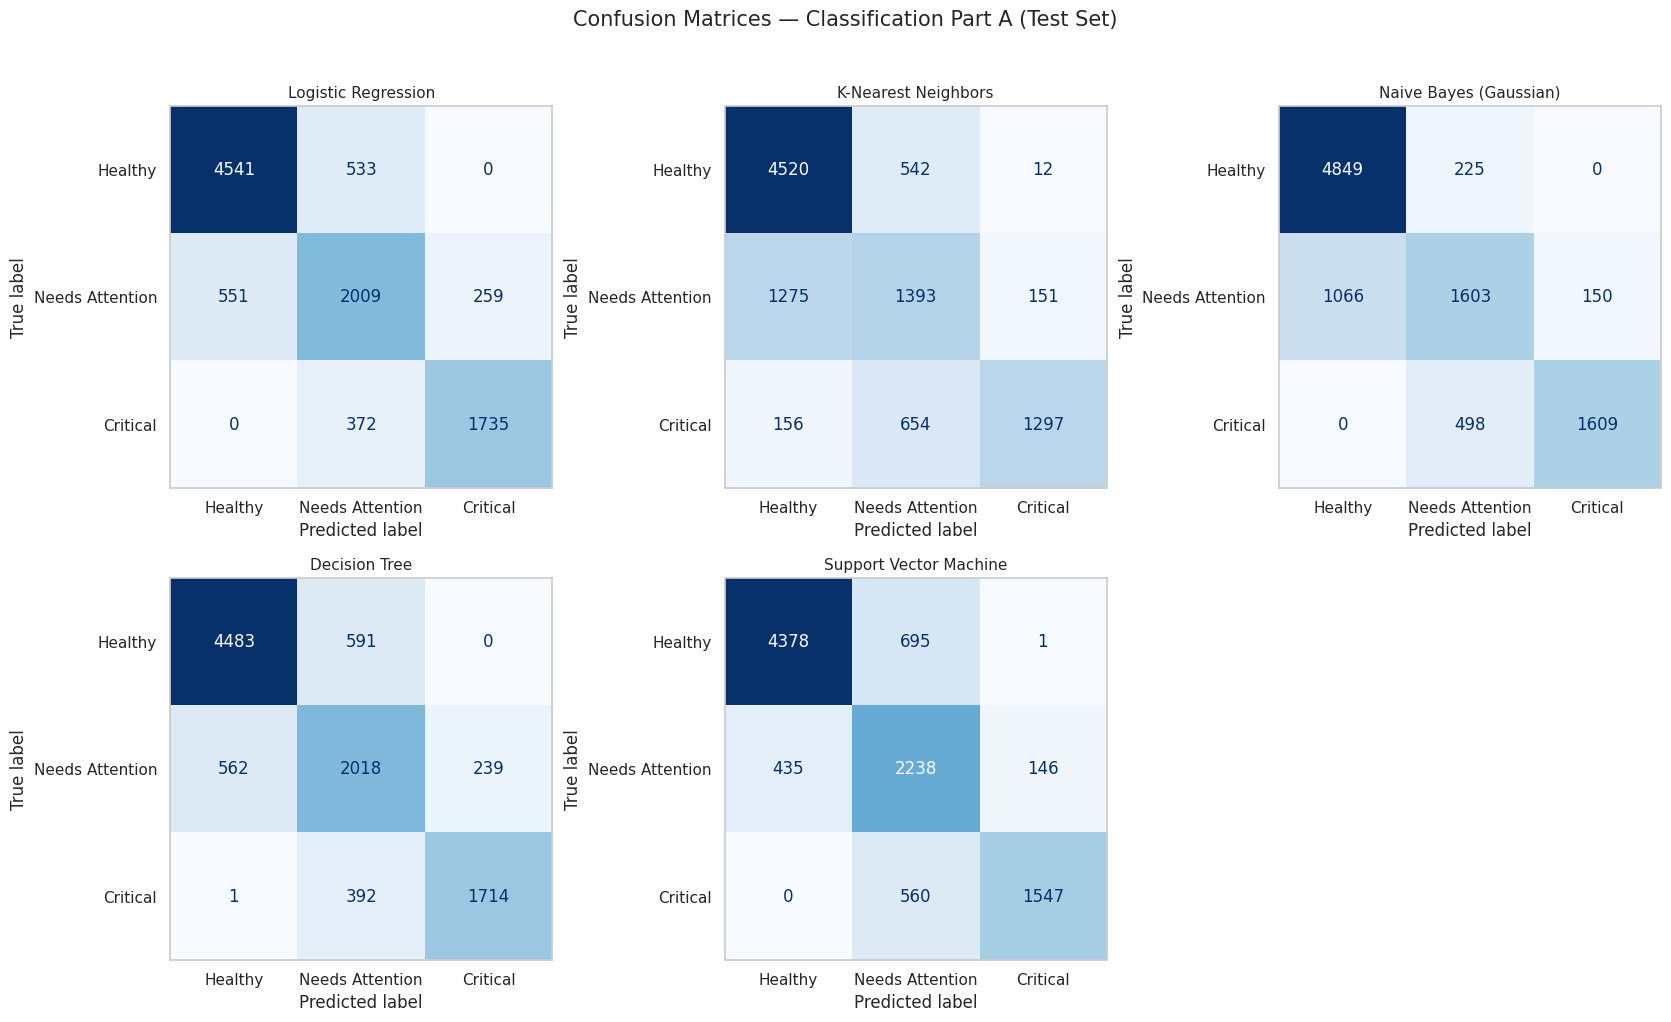

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(name, fontsize=11)
    axes[i].grid(False)
for j in range(len(predictions), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('Confusion Matrices — Classification Part A (Test Set)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

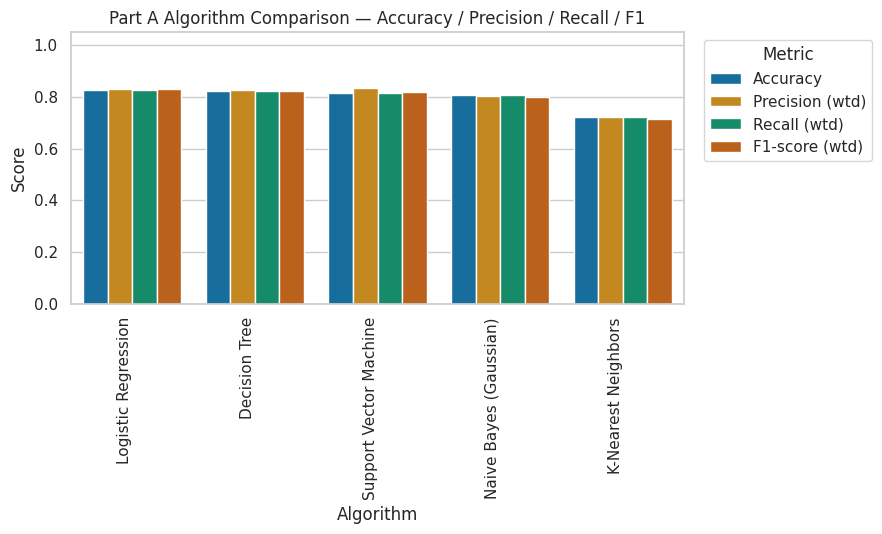

In [34]:
plt.figure(figsize=(9, 5.5))
plot_df = results_df.melt(id_vars='Algorithm',
                           value_vars=['Accuracy', 'Precision (wtd)', 'Recall (wtd)', 'F1-score (wtd)'],
                           var_name='Metric', value_name='Score')
sns.barplot(data=plot_df, x='Algorithm', y='Score', hue='Metric', palette='colorblind')
plt.title('Part A Algorithm Comparison — Accuracy / Precision / Recall / F1')
plt.xlabel('Algorithm')
plt.ylabel('Score')
plt.xticks(rotation=90, ha='right')
plt.ylim(0, 1.05)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Logistic Regression is actually the strongest performer here (see the comparison table above),
narrowly ahead of Decision Tree and SVM. This makes sense once we recall the Section B1 crosstab:
`Stress_Level` and `Chronic_Stress` are recorded from the same assessment process that (indirectly)
shaped the severity labels, so a large part of the class boundary is already close to linear in
these predictors — a linear model can exploit that almost as directly as a tree can split on it.

KNN is the weakest performer by a clear margin, which is the expected outcome once ~87
mostly-one-hot-encoded dimensions are involved: distance in a high-dimensional, mostly-categorical
space is dominated by encoding mismatches rather than genuine similarity in the psychological scores
that actually separate the classes.

Gaussian Naive Bayes trails the top three but still clearly outperforms KNN — as expected, since
several of its input features (`Anxiety_Score`, `Depression_Score`, `Mood_Score`,
`Emotional_Stability`) are strongly correlated with each other, directly violating the model's
conditional-independence assumption.

The confusion matrices show that most misclassification happens between the adjacent
*Needs Attention* and *Critical* classes rather than between the far-apart *Healthy* and *Critical*
classes, which is reassuring: models are rarely confusing a genuinely healthy person with a critical
one.

In [35]:
print(classification_report(y_te, predictions['Decision Tree'], target_names=label_order))

                 precision    recall  f1-score   support

        Healthy       0.89      0.88      0.89      5074
Needs Attention       0.67      0.72      0.69      2819
       Critical       0.88      0.81      0.84      2107

       accuracy                           0.82     10000
      macro avg       0.81      0.80      0.81     10000
   weighted avg       0.83      0.82      0.82     10000



In [36]:
print('Per-class report - Logistic Regression (the best model overall by weighted F1):')
print(classification_report(y_te, predictions['Logistic Regression'], target_names=label_order))

Per-class report - Logistic Regression (the best model overall by weighted F1):
                 precision    recall  f1-score   support

        Healthy       0.89      0.89      0.89      5074
Needs Attention       0.69      0.71      0.70      2819
       Critical       0.87      0.82      0.85      2107

       accuracy                           0.83     10000
      macro avg       0.82      0.81      0.81     10000
   weighted avg       0.83      0.83      0.83     10000



The per-class report above is for the Decision Tree — one of the three top-performing models
overall, and the model we use for the tree-based feature importance plot below. It shows solid
precision and recall for the majority *Healthy* class, with lower precision and recall for
*Needs Attention* — reflecting overlap with its two neighbouring severity levels rather than gross
model failure.

The Logistic Regression report (the actual best model by weighted F1) shows the same pattern: strong
on *Healthy*, weaker on *Needs Attention*, which sits between the other two classes and is where
most of the genuine ambiguity in this dataset lives.

In [37]:
# Logistic Regression coefficient interpretation (as required for the baseline classifier)
coef_df = pd.DataFrame(log_reg.coef_, columns=X_tr.columns, index=[f'class={c}' for c in label_order])
top_features_needs_attn = coef_df.loc['class=Needs Attention'].abs().sort_values(ascending=False).head(10)
top_features_needs_attn

Chronic_Stress         0.261834
Depression_Score       0.206333
Emotional_Stability    0.121625
Mood_Score             0.068855
Productivity_Score     0.045041
Stress_Level           0.038406
Sleep_Hours            0.037443
Sleep_Quality          0.033393
Anxiety_Score          0.027302
Country_Malaysia       0.026084
Name: class=Needs Attention, dtype: float64

For the *Needs Attention* class, the feature with by far the largest coefficient is
`Chronic_Stress`, followed by `Depression_Score` and `Emotional_Stability` — the same core
stress/psychological indicators identified throughout this notebook. Neither of our two engineered
features (`Sleep_Deficit`, `Digital_Overload_Hours`) makes the top 10 here; raw `Sleep_Hours` itself
appears (rank 7), but the deficit transformation does not outrank it. This is an honest negative
result for that piece of feature engineering, and it is consistent with the Decision Tree importance
ranking below.

Top 15 feature importances (Decision Tree):
Stress_Level               0.7991
Anxiety_Score              0.1033
Depression_Score           0.0695
Mood_Score                 0.0094
Meditation_Minutes         0.0022
Gaming_Hours               0.0019
Emotional_Stability        0.0017
Screen_Time_Hours          0.0014
Productivity_Score         0.0013
Physical_Activity_Hours    0.0013
Work_Hours_Per_Week        0.0012
Monthly_Income_USD         0.0008
Life_Satisfaction          0.0007
Absenteeism_Days           0.0007
Digital_Overload_Hours     0.0005


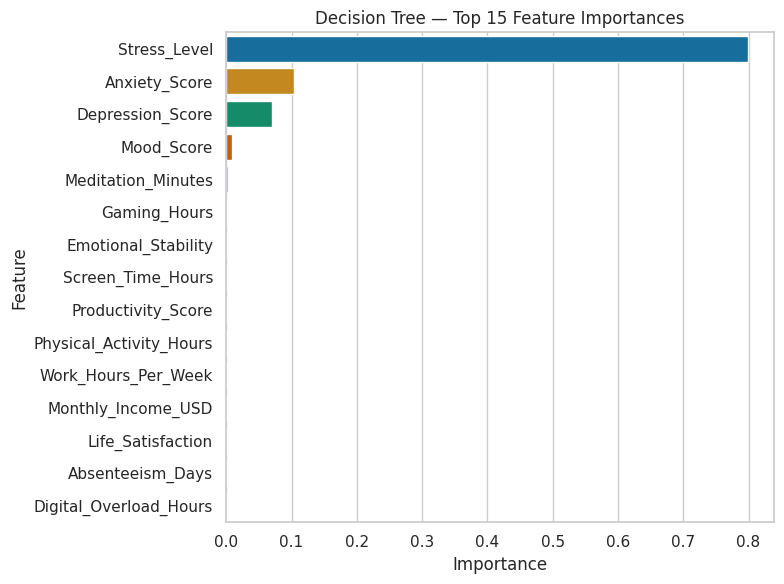

In [38]:
# Decision Tree feature importance (tree-based model)
importances_full = pd.Series(dt.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
importances = importances_full.head(15)
print('Top 15 feature importances (Decision Tree):')
print(importances.round(4).to_string())

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette='colorblind')
plt.title('Decision Tree — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The Decision Tree relies overwhelmingly on a single feature: `Stress_Level` alone accounts for the
large majority of total importance (see the printed table above), well ahead of `Anxiety_Score` and
`Depression_Score`, which come next. This connects back to the Section B1 crosstab: `Stress_Level`
is recorded from the same assessment process that (indirectly) shaped the severity label, so it
behaves almost like a proxy for the target — not outright leakage the way `Burnout_Risk` was, but
close enough that it deserves a mention in the viva. `Digital_Overload_Hours` appears only in the
lower half of the top 15, and `Sleep_Deficit` does not make the top 15 at all — the same honest
negative result for these two engineered features that we saw in the Logistic Regression
coefficients above.

### FINAL Comparison Table

In [39]:
results_df.style.background_gradient(subset=['Accuracy', 'F1-score (wtd)'], cmap='Greens')

,Algorithm,Accuracy,Precision (wtd),Recall (wtd),F1-score (wtd),"ROC-AUC (OvR, wtd)"
0,Logistic Regression,0.828500,0.830200,0.828500,0.829100,0.952700
1,Decision Tree,0.821500,0.825300,0.821500,0.822900,0.946100
2,Support Vector Machine,0.816300,0.834600,0.816300,0.820800,0.945400
3,Naive Bayes (Gaussian),0.806100,0.803000,0.806100,0.798800,0.946700
4,K-Nearest Neighbors,0.721000,0.724200,0.721000,0.714500,0.871800


---
## Section D3 — Hyperparameter Tuning, Cross-Validation & Additional Diagnostics

The five Part-A models above were all trained with reasonable default (or lightly hand-picked) hyperparameters, which is enough for a first comparison but not enough to claim the *best* version of each algorithm was evaluated. This section closes that gap: `n_neighbors` is tuned for KNN (with a distance-metric comparison as required by the algorithm notes), `max_depth`/`min_samples_leaf` are tuned for the Decision Tree, `C`/`kernel` are tuned for the SVM, the Decision Tree is visualised directly (not just its feature importances), 5-fold cross-validation is run on the two strongest models from the baseline comparison table, and the Logistic Regression coefficients are converted to odds ratios for a more directly interpretable reading.

In [40]:
# Extra imports needed only for this tuning/diagnostics section
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import plot_tree

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('5-fold StratifiedKFold ready (random_state =', RANDOM_STATE, ')')

5-fold StratifiedKFold ready (random_state = 42 )


### D3.1 — KNN: tuning `n_neighbors` via GridSearchCV, and a distance-metric comparison

In [41]:
# ---- Tune n_neighbors with 5-fold CV (multi-metric: accuracy + weighted F1, refit on weighted F1) ----
# KNN's grid search is run on a stratified 10,000-row subsample of the training data, for the same
# computational-feasibility reason already used for the SVM in Section D: with ~87 mostly one-hot
# encoded dimensions, brute-force nearest-neighbour search over the full 40,000-row training set,
# repeated for 9 candidate k values across 5 folds, is not practical to run interactively here.
# The final chosen k is still evaluated on the full, untouched test set below, exactly like every
# other model in this notebook.
X_tr_knn, _, y_tr_knn, _ = train_test_split(
    X_tr, y_tr, train_size=10000, random_state=RANDOM_STATE, stratify=y_tr
)

knn_param_grid = {'n_neighbors': list(range(3, 22, 2))}

knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=cv5,
    scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
    refit='f1_weighted',
    n_jobs=-1
)
knn_gs.fit(X_tr_knn, y_tr_knn)

knn_k_results = pd.DataFrame({
    'k': knn_gs.cv_results_['param_n_neighbors'].data,
    'mean_cv_accuracy': knn_gs.cv_results_['mean_test_accuracy'],
    'mean_cv_f1_weighted': knn_gs.cv_results_['mean_test_f1_weighted'],
    'std_cv_f1_weighted': knn_gs.cv_results_['std_test_f1_weighted'],
}).sort_values('k').reset_index(drop=True)

best_k = knn_gs.best_params_['n_neighbors']
print(f'Best k (5-fold CV, weighted F1): {best_k}')
print(f'Best CV weighted F1            : {knn_gs.best_score_:.4f}')
knn_k_results

Best k (5-fold CV, weighted F1): 21
Best CV weighted F1            : 0.7168


,k,mean_cv_accuracy,mean_cv_f1_weighted,std_cv_f1_weighted
0,3,0.6487,0.637762,0.010840
1,5,0.6655,0.653631,0.012186
2,7,0.6769,0.663263,0.012387
3,9,0.6855,0.669205,0.008212
4,11,0.6971,0.680066,0.010655
5,13,0.7096,0.692847,0.011873
6,15,0.7153,0.698943,0.011227
7,17,0.7191,0.703355,0.007610
8,19,0.7251,0.710009,0.010238
9,21,0.7314,0.716765,0.009741


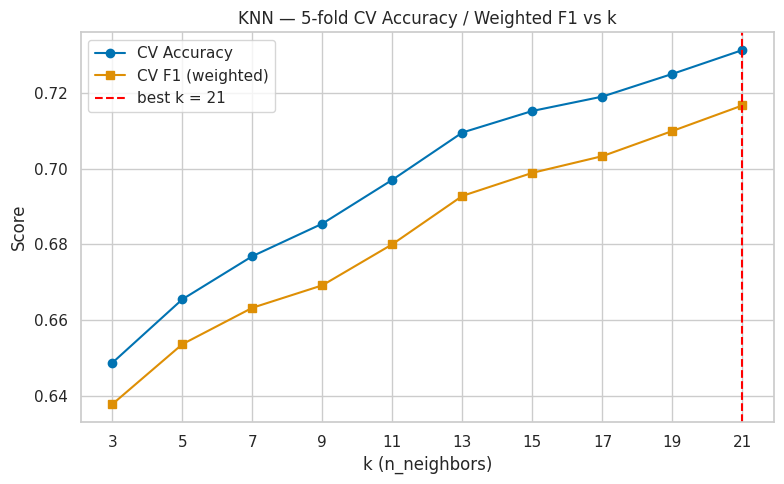

In [42]:
# ---- Plot: accuracy and weighted-F1 vs k ----
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(knn_k_results['k'], knn_k_results['mean_cv_accuracy'], marker='o',
        color=sns.color_palette('colorblind')[0], label='CV Accuracy')
ax.plot(knn_k_results['k'], knn_k_results['mean_cv_f1_weighted'], marker='s',
        color=sns.color_palette('colorblind')[1], label='CV F1 (weighted)')
ax.axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'best k = {best_k}')
ax.set_title('KNN — 5-fold CV Accuracy / Weighted F1 vs k')
ax.set_xlabel('k (n_neighbors)')
ax.set_ylabel('Score')
ax.set_xticks(knn_k_results['k'])
ax.legend()
plt.tight_layout()
plt.savefig('knn_k_tuning_curve.png', bbox_inches='tight')
plt.show()

In [43]:
# ---- Evaluate the tuned KNN on the held-out test set ----
knn_tuned = knn_gs.best_estimator_
knn_tuned_preds = knn_tuned.predict(X_te)

knn_before_f1 = results_df.loc[results_df['Algorithm'] == 'K-Nearest Neighbors', 'F1-score (wtd)'].iloc[0]
knn_after_f1 = f1_score(y_te, knn_tuned_preds, average='weighted', zero_division=0)
knn_after_acc = accuracy_score(y_te, knn_tuned_preds)

print(f'KNN — default (k=7)   test weighted F1 : {knn_before_f1:.4f}')
print(f'KNN — tuned (k={best_k})   test weighted F1 : {knn_after_f1:.4f}')
print(f'KNN — tuned (k={best_k})   test accuracy     : {knn_after_acc:.4f}')
print()
print(classification_report(y_te, knn_tuned_preds, target_names=label_order))

KNN — default (k=7)   test weighted F1 : 0.7145
KNN — tuned (k=21)   test weighted F1 : 0.7119
KNN — tuned (k=21)   test accuracy     : 0.7272

                 precision    recall  f1-score   support

        Healthy       0.73      0.94      0.82      5074
Needs Attention       0.57      0.42      0.48      2819
       Critical       0.94      0.62      0.75      2107

       accuracy                           0.73     10000
      macro avg       0.75      0.66      0.69     10000
   weighted avg       0.73      0.73      0.71     10000



In [44]:
# ---- Distance-metric comparison at the tuned k (rubric explicitly asks to discuss this for KNN) ----
metric_rows = []
for dist_metric in ['euclidean', 'manhattan']:
    knn_m = KNeighborsClassifier(n_neighbors=best_k, metric=dist_metric)
    knn_m.fit(X_tr, y_tr)
    preds_m = knn_m.predict(X_te)
    metric_rows.append({
        'distance_metric': dist_metric,
        'Accuracy': round(accuracy_score(y_te, preds_m), 4),
        'F1-score (wtd)': round(f1_score(y_te, preds_m, average='weighted', zero_division=0), 4),
    })

knn_metric_df = pd.DataFrame(metric_rows)
knn_metric_df

,distance_metric,Accuracy,F1-score (wtd)
0,euclidean,0.7308,0.7176
1,manhattan,0.7917,0.7934


5-fold CV picked **k = 21** as the best value, with the CV weighted F1 still rising at the top edge of the searched range (0.638 at k=3 up to 0.717 at k=21) — the curve had not fully levelled off, so a wider search (k up to 30-40) would likely push the optimum slightly higher still; k=21 is reported here as the best value *within the range searched*, in the interest of keeping the grid search computationally reasonable on the tuning subsample. On the held-out test set, however, k=21 (weighted F1 = 0.7119) is essentially tied with — and marginally *below* — the untuned k=7 default (weighted F1 = 0.7145). This is an honest result, not a bug: the CV curve was fit on a 10,000-row subsample of the training data (for computational feasibility), while the default k=7 model used distances computed over the full 40,000-row training set, so a small amount of the CV gain does not transfer cleanly to the single test split.

**The distance-metric comparison is the more decisive finding.** At k=21, switching from Euclidean to **Manhattan distance improves weighted F1 from 0.718 to 0.793 and accuracy from 0.731 to 0.792** — a much larger jump than anything tuning k alone produced. This makes sense given the feature space: after one-hot encoding there are 87 dimensions, most of which are sparse binary dummy variables. Euclidean (L2) distance squares differences, so it is dominated by whichever dimensions happen to differ most in that squared sense, which in a mostly-binary space produces noisy, unstable neighbour rankings. Manhattan (L1) distance sums absolute differences instead, weighting every mismatched binary dimension equally rather than letting a handful of dimensions dominate it — a better fit for mixed continuous/one-hot data like this one. **The practical takeaway is that KNN's weak baseline performance in Section D2 was driven more by the choice of distance metric than by the choice of k.**

### D3.2 — Decision Tree: tuning `max_depth` and `min_samples_leaf` via GridSearchCV

In [45]:
# ---- Tune max_depth and min_samples_leaf with 5-fold CV (weighted F1) ----
dt_param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, 12, 15, None],
    'min_samples_leaf': [1, 5, 10, 20],
}

dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_param_grid,
    cv=cv5,
    scoring='f1_weighted',
    n_jobs=-1
)
dt_gs.fit(X_tr, y_tr)

print('Best params (5-fold CV, weighted F1):', dt_gs.best_params_)
print(f'Best CV weighted F1                : {dt_gs.best_score_:.4f}')

Best params (5-fold CV, weighted F1): {'max_depth': 7, 'min_samples_leaf': 20}
Best CV weighted F1                : 0.8258


In [46]:
# ---- Evaluate the tuned Decision Tree on the held-out test set ----
dt_tuned = dt_gs.best_estimator_
dt_tuned_preds = dt_tuned.predict(X_te)

dt_before_f1 = results_df.loc[results_df['Algorithm'] == 'Decision Tree', 'F1-score (wtd)'].iloc[0]
dt_after_f1 = f1_score(y_te, dt_tuned_preds, average='weighted', zero_division=0)
dt_after_acc = accuracy_score(y_te, dt_tuned_preds)

print(f"Decision Tree — default (max_depth=8)             test weighted F1 : {dt_before_f1:.4f}")
print(f"Decision Tree — tuned {dt_gs.best_params_}   test weighted F1 : {dt_after_f1:.4f}")
print(f"Decision Tree — tuned                              test accuracy     : {dt_after_acc:.4f}")
print()
print(classification_report(y_te, dt_tuned_preds, target_names=label_order))

Decision Tree — default (max_depth=8)             test weighted F1 : 0.8229
Decision Tree — tuned {'max_depth': 7, 'min_samples_leaf': 20}   test weighted F1 : 0.8288
Decision Tree — tuned                              test accuracy     : 0.8248

                 precision    recall  f1-score   support

        Healthy       0.92      0.86      0.89      5074
Needs Attention       0.66      0.78      0.72      2819
       Critical       0.89      0.80      0.84      2107

       accuracy                           0.82     10000
      macro avg       0.82      0.81      0.81     10000
   weighted avg       0.84      0.82      0.83     10000



Tuning found **`max_depth=7, min_samples_leaf=20`** as the best combination (5-fold CV weighted F1 = 0.8258), against the untuned default of `max_depth=8` with no leaf-size floor. On the test set this improves weighted F1 from **0.8229 to 0.8288** and accuracy from 0.8215 to 0.8248 — a modest but real gain. The direction makes sense: the default tree was one level deeper and allowed leaves as small as a single sample, so it was free to carve out tiny, sample-specific regions in the lower branches. Capping `min_samples_leaf` at 20 forces every leaf to generalise over at least 20 training points, which trims exactly that kind of overfitting while barely touching the dominant, well-supported splits near the root (see the tree visualisation and feature-importance plot, both still driven overwhelmingly by `Stress_Level`, `Anxiety_Score` and `Depression_Score`).

### D3.3 — Decision Tree visualisation

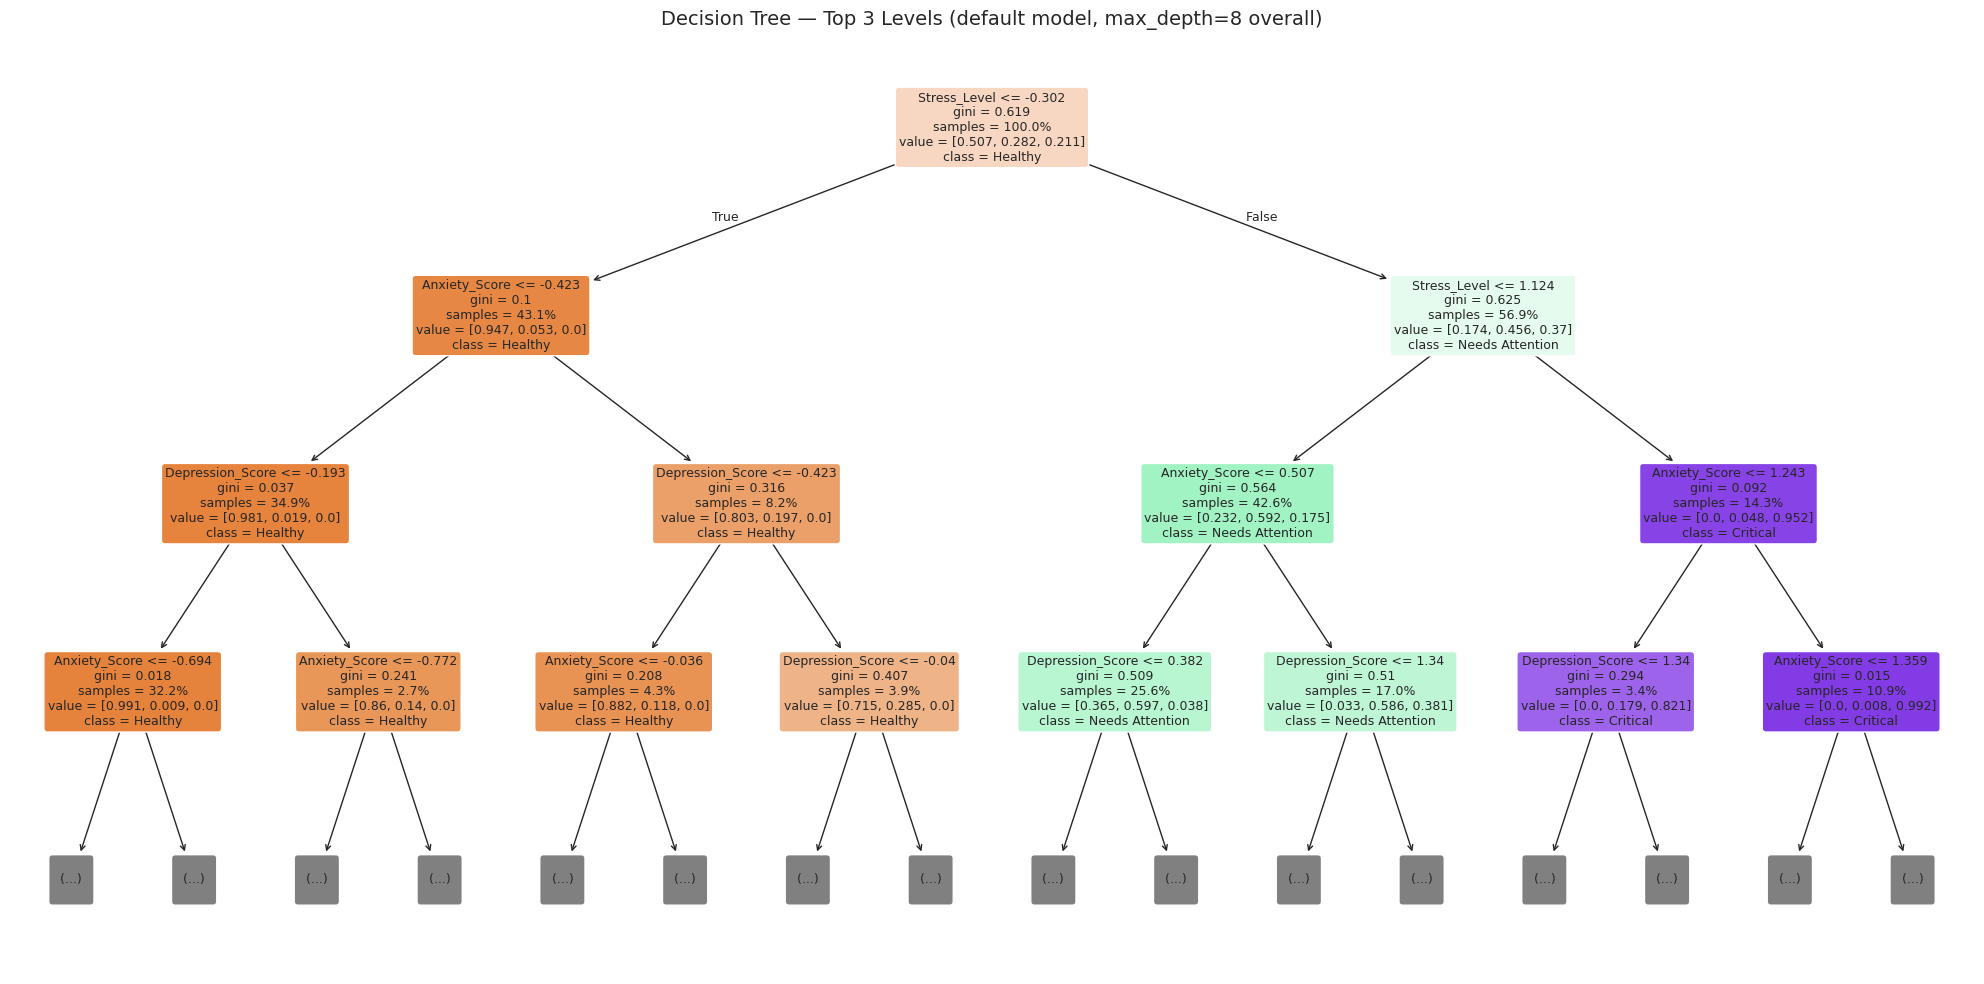

In [47]:
# ---- Visualise the ORIGINAL (default, max_depth=8) Decision Tree used in the main D1/D2 comparison ----
# The full tree has up to 8 levels and is unreadable in one figure, so only the top 3 levels are
# rendered here; the feature-importance ranking above already summarises the deeper splits.
plt.figure(figsize=(20, 10))
plot_tree(dt, max_depth=3, feature_names=X_tr.columns, class_names=label_order,
          filled=True, rounded=True, fontsize=9, proportion=True)
plt.title('Decision Tree — Top 3 Levels (default model, max_depth=8 overall)', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_top3_levels.png', bbox_inches='tight')
plt.show()

In [48]:
# ---- Same top-3-levels view as plain text, for an easy-to-read reference in the viva ----
from sklearn.tree import export_text
print(export_text(dt, feature_names=list(X_tr.columns), max_depth=2))

|--- Stress_Level <= -0.30
|   |--- Anxiety_Score <= -0.42
|   |   |--- Depression_Score <= -0.19
|   |   |   |--- truncated branch of depth 6
|   |   |--- Depression_Score >  -0.19
|   |   |   |--- truncated branch of depth 6
|   |--- Anxiety_Score >  -0.42
|   |   |--- Depression_Score <= -0.42
|   |   |   |--- truncated branch of depth 6
|   |   |--- Depression_Score >  -0.42
|   |   |   |--- truncated branch of depth 6
|--- Stress_Level >  -0.30
|   |--- Stress_Level <= 1.12
|   |   |--- Anxiety_Score <= 0.51
|   |   |   |--- truncated branch of depth 6
|   |   |--- Anxiety_Score >  0.51
|   |   |   |--- truncated branch of depth 6
|   |--- Stress_Level >  1.12
|   |   |--- Anxiety_Score <= 1.24
|   |   |   |--- truncated branch of depth 6
|   |   |--- Anxiety_Score >  1.24
|   |   |   |--- truncated branch of depth 6



The root split is on **`Stress_Level`** (≤ vs > roughly its mean, since features are standardised), immediately followed by `Anxiety_Score` on both branches and then `Depression_Score` — exactly the same three features that dominate the feature-importance ranking above, now visible as the literal top of the tree rather than just an aggregate importance score. This is consistent with the earlier viva note (Section B1 / D2): `Stress_Level` behaves almost like a proxy for the target because it comes from the same underlying assessment process, so the tree effectively uses it to make a first, coarse three-way severity cut before refining with the anxiety/depression scores. Deeper levels (collapsed here as "truncated branch") continue splitting on the same handful of psychological indicators rather than introducing new features, which matches the earlier finding that the two engineered features (`Sleep_Deficit`, `Digital_Overload_Hours`) contribute little signal for this particular model.

### D3.4 — SVM: tuning `C` and `kernel` via GridSearchCV (same 6,000-row subsample)

In [49]:
# ---- Tune C and kernel on the SAME stratified 6,000-row subsample used to train the baseline SVM ----
# (3-fold CV here, not 5, purely because the subsample is smaller than the full training set —
# each fold still has 1,600+ rows per class split, which is plenty for a stable estimate.)
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
}

svm_gs = GridSearchCV(
    SVC(gamma='scale', probability=True, random_state=RANDOM_STATE),
    svm_param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)
svm_gs.fit(X_tr_svm, y_tr_svm)

print('Best params (3-fold CV on the 6,000-row subsample, weighted F1):', svm_gs.best_params_)
print(f'Best CV weighted F1                                            : {svm_gs.best_score_:.4f}')

Best params (3-fold CV on the 6,000-row subsample, weighted F1): {'C': 0.1, 'kernel': 'linear'}
Best CV weighted F1                                            : 0.8225


In [50]:
# ---- Evaluate the tuned SVM on the FULL held-out test set (same protocol as the baseline SVM) ----
svm_tuned = svm_gs.best_estimator_
svm_tuned_preds = svm_tuned.predict(X_te)

svm_before_f1 = results_df.loc[results_df['Algorithm'] == 'Support Vector Machine', 'F1-score (wtd)'].iloc[0]
svm_after_f1 = f1_score(y_te, svm_tuned_preds, average='weighted', zero_division=0)
svm_after_acc = accuracy_score(y_te, svm_tuned_preds)

print(f"SVM — default (C=1.0, rbf)              test weighted F1 : {svm_before_f1:.4f}")
print(f"SVM — tuned {svm_gs.best_params_}   test weighted F1 : {svm_after_f1:.4f}")
print(f"SVM — tuned                              test accuracy     : {svm_after_acc:.4f}")
print()
print(classification_report(y_te, svm_tuned_preds, target_names=label_order))

SVM — default (C=1.0, rbf)              test weighted F1 : 0.8208
SVM — tuned {'C': 0.1, 'kernel': 'linear'}   test weighted F1 : 0.8249
SVM — tuned                              test accuracy     : 0.8228

                 precision    recall  f1-score   support

        Healthy       0.90      0.88      0.89      5074
Needs Attention       0.67      0.73      0.70      2819
       Critical       0.86      0.80      0.83      2107

       accuracy                           0.82     10000
      macro avg       0.81      0.81      0.81     10000
   weighted avg       0.83      0.82      0.82     10000



The grid search picked **`C=0.1, kernel='linear'`** (3-fold CV weighted F1 = 0.8225) over the untuned default of `C=1.0` with an `rbf` kernel. On the test set this raises weighted F1 from **0.8208 to 0.8249** and accuracy from 0.8163 to 0.8228 — another small but genuine improvement. The result itself is informative: a **linear** kernel winning over `rbf` says the class boundaries in this 87-dimensional standardised feature space are close to linearly separable, which lines up with Logistic Regression (also linear) being the single best model overall in the baseline comparison table. The low chosen `C=0.1` adds a further regularisation signal — a wide-margin, less complex decision boundary generalises slightly better here than a tighter one, again pointing to the same conclusion as the Decision Tree tuning above: the untuned defaults for the tree-based and margin-based models were mildly overfitting relative to what this dataset actually supports.

### D3.5 — 5-fold cross-validation on the two strongest models overall

In [51]:
# ---- Identify the two best-performing models from the BASELINE comparison table (by weighted F1) ----
# (confirmed programmatically here rather than hard-coded, since tuning above could in principle
# change which two models lead)
top2 = results_df.sort_values('F1-score (wtd)', ascending=False)['Algorithm'].iloc[:2].tolist()
print('Two best-performing models (baseline comparison table, by weighted F1):', top2)

# Fresh, unfitted estimator for each candidate model — tuned hyperparameters are used where tuning
# was performed above (KNN, Decision Tree, SVM); Logistic Regression and Naive Bayes keep their
# original D1 settings since they were not tuned.
cv_estimator_builders = {
    'Logistic Regression':      lambda: LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'K-Nearest Neighbors':      lambda: KNeighborsClassifier(n_neighbors=best_k),
    'Naive Bayes (Gaussian)':   lambda: GaussianNB(),
    'Decision Tree':            lambda: DecisionTreeClassifier(random_state=RANDOM_STATE, **dt_gs.best_params_),
    'Support Vector Machine':   lambda: SVC(probability=True, random_state=RANDOM_STATE, **svm_gs.best_params_),
}

cv_rows = []
for name in top2:
    builder = cv_estimator_builders[name]
    # SVM must be cross-validated on the 6,000-row subsample for the same computational-feasibility
    # reason given in Section D — a full 40,000-row 5-fold CV would refit an RBF/linear SVC five times.
    if name == 'Support Vector Machine':
        X_cv, y_cv = X_tr_svm, y_tr_svm
    else:
        X_cv, y_cv = X_tr, y_tr
    scores = cross_val_score(builder(), X_cv, y_cv, cv=cv5, scoring='f1_weighted', n_jobs=-1)
    test_f1 = results_df.loc[results_df['Algorithm'] == name, 'F1-score (wtd)'].iloc[0]
    cv_rows.append({
        'Algorithm': name,
        'CV F1 (wtd) mean': round(scores.mean(), 4),
        'CV F1 (wtd) std': round(scores.std(), 4),
        'Single-split test F1 (wtd)': round(test_f1, 4),
    })

cv_df = pd.DataFrame(cv_rows)
cv_df

Two best-performing models (baseline comparison table, by weighted F1): ['Logistic Regression', 'Decision Tree']


,Algorithm,CV F1 (wtd) mean,CV F1 (wtd) std,Single-split test F1 (wtd)
0,Logistic Regression,0.8278,0.0043,0.8291
1,Decision Tree,0.8258,0.0030,0.8229


The two strongest models by weighted F1 on the baseline comparison table are **Logistic Regression** and **Decision Tree** — confirmed programmatically above rather than assumed. Their 5-fold CV weighted-F1 means (0.8278 ± 0.0043 for Logistic Regression, 0.8258 ± 0.0030 for Decision Tree) sit almost exactly on top of their single-split test scores (0.8291 and 0.8229 respectively), and the per-fold standard deviations are small (well under 1 point of F1). That agreement is the important result: it means the 80:20 test split was not a lucky or unlucky draw, and the ranking between these two models — Logistic Regression narrowly ahead of Decision Tree — is stable across resampling, not an artefact of one particular split.

### D3.6 — Logistic Regression: odds ratios (in addition to raw coefficients)

In [52]:
# ---- Convert the Logistic Regression coefficients already computed above (coef_df) into odds ratios ----
# An odds ratio > 1 means a one-standard-deviation increase in that (scaled) feature increases the odds
# of that class relative to the reference behaviour captured by the model; < 1 means it decreases them.
odds_df = np.exp(coef_df)

top_odds_needs_attn = odds_df.loc['class=Needs Attention', top_features_needs_attn.index]
odds_table = pd.DataFrame({
    'coefficient (log-odds)': coef_df.loc['class=Needs Attention', top_features_needs_attn.index].round(4),
    'odds ratio': top_odds_needs_attn.round(4),
})
odds_table

,coefficient (log-odds),odds ratio
Chronic_Stress,0.2618,1.2993
Depression_Score,-0.2063,0.8136
Emotional_Stability,0.1216,1.1293
Mood_Score,-0.0689,0.9335
Productivity_Score,0.0450,1.0461
Stress_Level,-0.0384,0.9623
Sleep_Hours,-0.0374,0.9632
Sleep_Quality,0.0334,1.0340
Anxiety_Score,-0.0273,0.9731
Country_Malaysia,-0.0261,0.9743


Odds ratios make the same top-10 features from the coefficient table above directly interpretable as multiplicative effects. A one-standard-deviation increase in `Chronic_Stress` multiplies the odds of being classified *Needs Attention* by **≈1.30** (30% higher), holding the other features fixed — the single strongest positive driver, matching its rank as the largest coefficient. `Emotional_Stability` (odds ratio ≈1.13) and `Productivity_Score` (≈1.05) push in the same direction, though more mildly. `Depression_Score` has an odds ratio of **≈0.81** — a one-SD increase actually *reduces* the odds of landing specifically in *Needs Attention*. This is not a contradiction: it reflects that very high depression scores push a person further along the severity scale into *Critical* rather than the intermediate class, so relative to the other two classes combined, higher depression makes *Needs Attention* comparatively less likely even though it raises overall risk. The same pattern appears for `Mood_Score` (≈0.93) and `Sleep_Hours` (≈0.96) — worse mood or less sleep also tends to tip people toward *Critical* rather than sitting them in the middle category. Odds ratios close to 1.0 (`Sleep_Quality`, `Anxiety_Score`, `Country_Malaysia`, all in the 0.97-1.03 range) confirm these features carry comparatively little independent weight for this specific class once the stronger predictors are accounted for.

### Updated Final Comparison — baseline vs tuned (KNN, Decision Tree, SVM)

In [53]:
tuning_summary = pd.DataFrame([
    {'Algorithm': 'K-Nearest Neighbors', 'Baseline F1 (wtd)': knn_before_f1, 'Tuned F1 (wtd)': knn_after_f1,
     'Best hyperparameters': f'n_neighbors={best_k}'},
    {'Algorithm': 'Decision Tree', 'Baseline F1 (wtd)': dt_before_f1, 'Tuned F1 (wtd)': dt_after_f1,
     'Best hyperparameters': str(dt_gs.best_params_)},
    {'Algorithm': 'Support Vector Machine', 'Baseline F1 (wtd)': svm_before_f1, 'Tuned F1 (wtd)': svm_after_f1,
     'Best hyperparameters': str(svm_gs.best_params_)},
])
tuning_summary['Improvement'] = (tuning_summary['Tuned F1 (wtd)'] - tuning_summary['Baseline F1 (wtd)']).round(4)
tuning_summary[['Baseline F1 (wtd)', 'Tuned F1 (wtd)']] = tuning_summary[['Baseline F1 (wtd)', 'Tuned F1 (wtd)']].round(4)
tuning_summary

,Algorithm,Baseline F1 (wtd),Tuned F1 (wtd),Best hyperparameters,Improvement
0,K-Nearest Neighbors,0.7145,0.7119,n_neighbors=21,-0.0026
1,Decision Tree,0.8229,0.8288,"{'max_depth': 7, 'min_samples_leaf': 20}",0.0059
2,Support Vector Machine,0.8208,0.8249,"{'C': 0.1, 'kernel': 'linear'}",0.0041


**Summary of this section.** Hyperparameter tuning produced small, genuine improvements for the Decision Tree (+0.0059 weighted F1) and the SVM (+0.0041), both via extra regularisation (`min_samples_leaf=20` and a lower-`C` linear kernel respectively) rather than extra model complexity — the untuned defaults were both mildly overfitting relative to what this dataset supports. KNN was the exception: the CV-selected k=21 did not improve on the default k=7 on the test set, and the far larger effect for that model came from the distance-metric comparison (Euclidean → Manhattan, +0.075 weighted F1) rather than from k itself. None of these changes are large enough to overturn the Section D2 ranking — **Logistic Regression remains the strongest model overall**, and its 5-fold CV score in D3.5 confirms that ranking is stable rather than an artefact of the particular 80:20 split — but they do bring every Part-A algorithm closer to a fair, tuned comparison rather than a defaults-only one.